In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Try to load the file we just made
try:
    df = pd.read_csv("students.csv")
    #Print the first 5 rows using .head()
    print("Success: The data is loaded!")
    print(df.head()) # Shows the first few students
except Exception as e:
    print(f"Error: Something went wrong. {e}")

import pandas as pd
import matplotlib.pyplot as plt

#Print the shape (rows × columns) and the data type of each column using .dtypes
# --- Task 1: Exploration ---
print("\n--- Dataset Info ---")
print(df.dtypes)
print(f"\nShape: {df.shape}")

#Print summary statistics (mean, min, max, std) for all numeric columns using .describe()
print("\n--- Summary Statistics ---")
print(df.describe())

#Print the count of students who passed and who failed
print("\n--- Pass/Fail Counts ---")
print(df['passed'].value_counts())

#Compute and print the average score per subject separately for passing and failing students
# Calculating averages by group
subject_cols = ['math', 'science', 'english', 'history', 'pe']
print("\n--- Avg Scores for Passing Students ---")
print(df[df['passed'] == 1][subject_cols].mean())

print("\n--- Avg Scores for Failing Students ---")
print(df[df['passed'] == 0][subject_cols].mean())

#Find and print the student with the highest overall average across all 5 subjects.
# Finding the top student
df['avg_score'] = df[subject_cols].mean(axis=1)
top_idx = df['avg_score'].idxmax()
print(f"\nTop Student: {df.loc[top_idx, 'name']} ({df.loc[top_idx, 'avg_score']:.2f})")



Success: The data is loaded!
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

--- Dataset Info ---
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Shape: (15, 9)

--- Summary Statistics ---
           

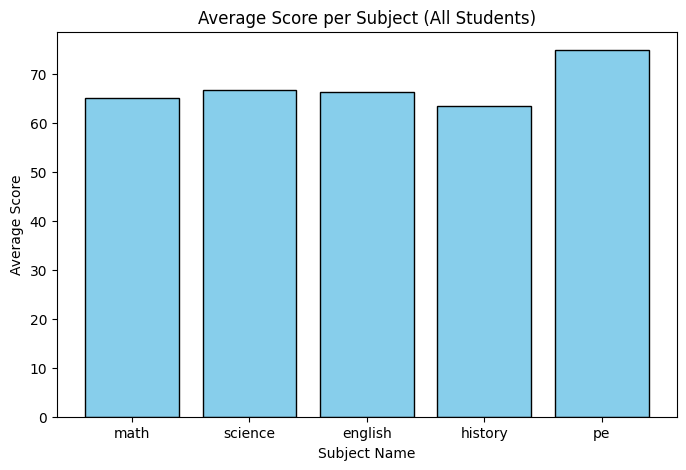

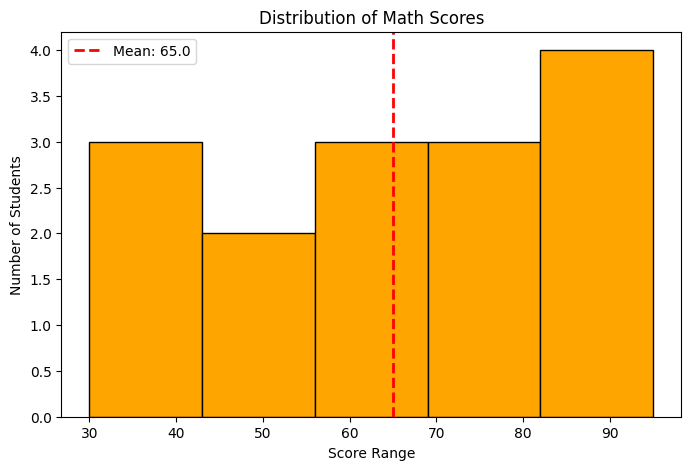

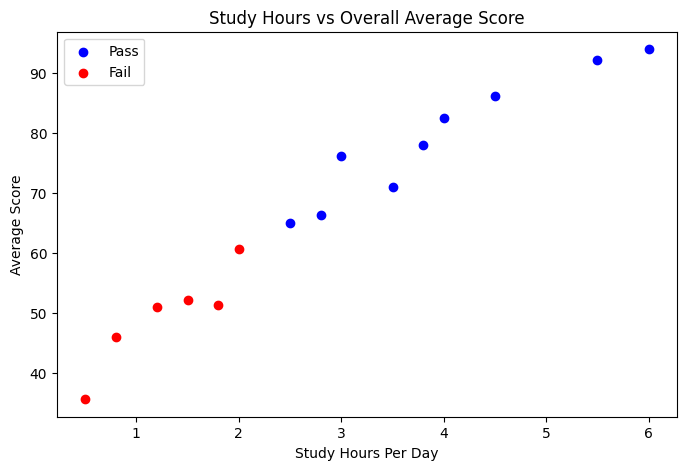

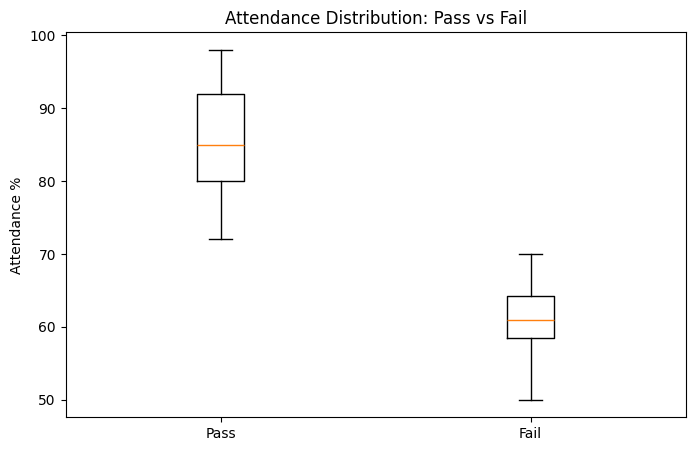

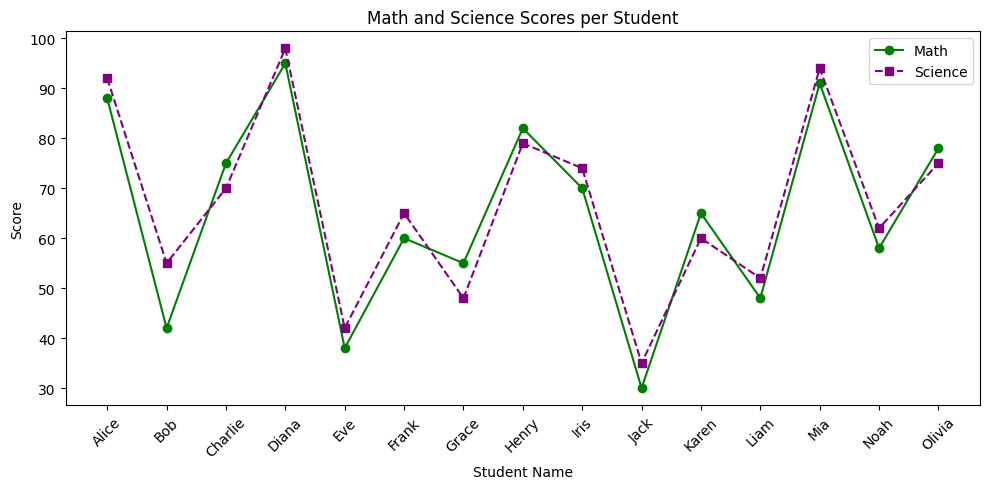

In [5]:
# --- Task 2: Matplotlib Visualizations ---
subject_cols = ['math', 'science', 'english', 'history', 'pe']

# 1. BAR CHART: Average score per subject
plt.figure(figsize=(8, 5))
subject_averages = df[subject_cols].mean()
plt.bar(subject_averages.index, subject_averages.values, color='skyblue', edgecolor='black')
plt.title("Average Score per Subject (All Students)")
plt.xlabel("Subject Name")
plt.ylabel("Average Score")
plt.savefig("plot1_bar.png")
plt.show()

# 2. HISTOGRAM: Distribution of Math scores
plt.figure(figsize=(8, 5))
plt.hist(df['math'], bins=5, color='orange', edgecolor='black')
math_mean = df['math'].mean()
plt.axvline(math_mean, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {math_mean:.1f}')
plt.title("Distribution of Math Scores")
plt.xlabel("Score Range")
plt.ylabel("Number of Students")
plt.legend()
plt.savefig("plot2_hist.png")
plt.show()

# 3. SCATTER PLOT: Study Hours vs Average Score
plt.figure(figsize=(8, 5))
pass_group = df[df['passed'] == 1]
fail_group = df[df['passed'] == 0]
plt.scatter(pass_group['study_hours_per_day'], pass_group['avg_score'], color='blue', label='Pass')
plt.scatter(fail_group['study_hours_per_day'], fail_group['avg_score'], color='red', label='Fail')
plt.title("Study Hours vs Overall Average Score")
plt.xlabel("Study Hours Per Day")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("plot3_scatter.png")
plt.show()

# 4. BOX PLOT: Attendance Percent (Pass vs Fail)
plt.figure(figsize=(8, 5))
pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

# FIXED: Changed 'labels' to 'tick_labels' to stop the warning
plt.boxplot([pass_attendance, fail_attendance], tick_labels=['Pass', 'Fail']) 
plt.title("Attendance Distribution: Pass vs Fail")
plt.ylabel("Attendance %")
plt.savefig("plot4_box.png")
plt.show()

# 5. LINE PLOT: Math and Science Scores per Student
plt.figure(figsize=(10, 5))
plt.plot(df['name'], df['math'], marker='o', label='Math', color='green')
plt.plot(df['name'], df['science'], marker='s', label='Science', color='purple', linestyle='--')
plt.title("Math and Science Scores per Student")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.xticks(rotation=45) 
plt.legend()
plt.tight_layout() 
plt.savefig("plot5_line.png")
plt.show()

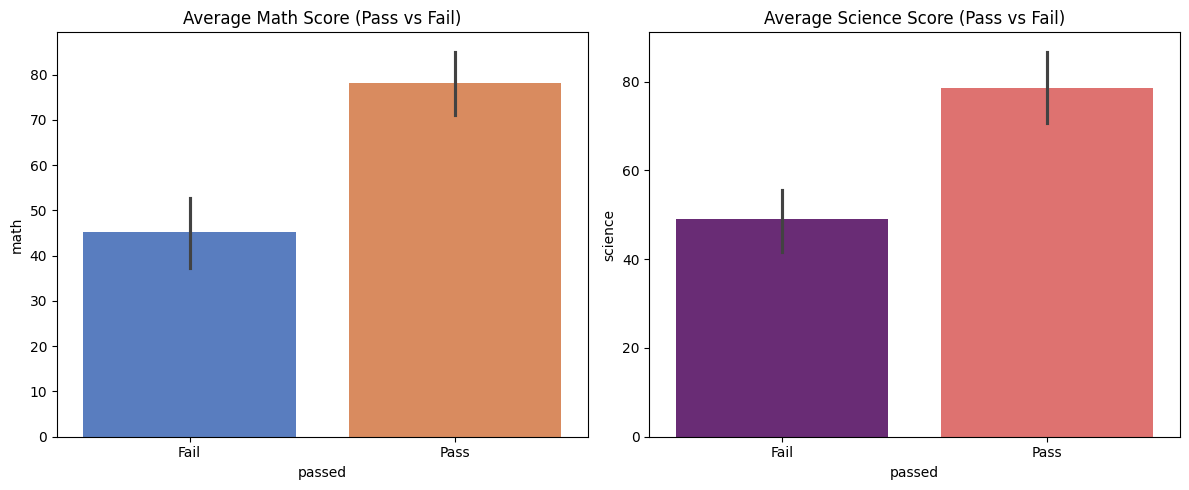

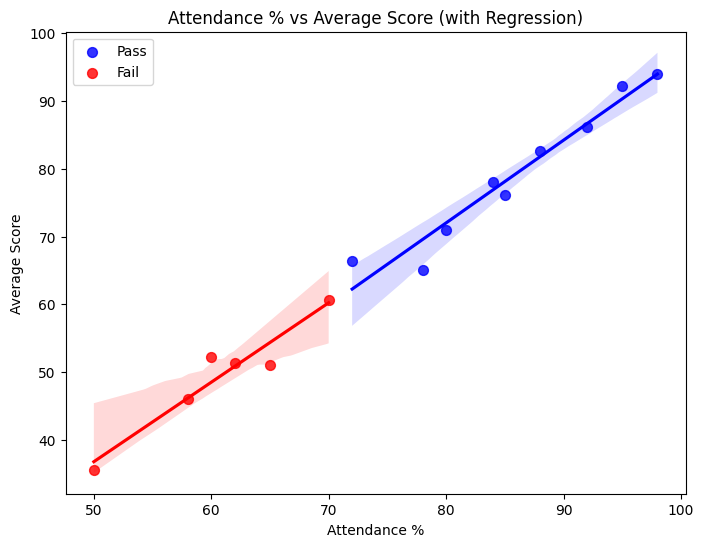

'\nComparison Comment:\nSeaborn felt much more intuitive for statistical plotting; for instance, adding a regression \nline only took one function call (sns.regplot) whereas Matplotlib would require manual \nmath calculations. However, Matplotlib still felt necessary for controlling the overall \nlayout and fine-tuning subplot details like titles and axis limits.\n'

In [7]:
## --- Task 3: Seaborn Visualizations ---
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Seaborn Bar Plots (Subplots for Math and Science)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Math Bar Plot
# We assign x to hue to satisfy the new Seaborn requirement
sns.barplot(data=df, x='passed', y='math', ax=ax1, hue='passed', palette='muted', legend=False)
ax1.set_title('Average Math Score (Pass vs Fail)')
# Using set_xticks before set_xticklabels fixes the UserWarning
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Fail', 'Pass'])

# Science Bar Plot
sns.barplot(data=df, x='passed', y='science', ax=ax2, hue='passed', palette='magma', legend=False)
ax2.set_title('Average Science Score (Pass vs Fail)')
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Fail', 'Pass'])

plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()

# 2. Seaborn Scatter Plot with Regression Lines
plt.figure(figsize=(8, 6))

# Plotting groups separately for clean regression lines
sns.regplot(data=df[df['passed']==1], x='attendance_pct', y='avg_score', label='Pass', color='blue', scatter_kws={'s':50})
sns.regplot(data=df[df['passed']==0], x='attendance_pct', y='avg_score', label='Fail', color='red', scatter_kws={'s':50})

plt.title('Attendance % vs Average Score (with Regression)')
plt.xlabel('Attendance %')
plt.ylabel('Average Score')
plt.legend()
plt.savefig("plot7_seaborn_scatter.png")
plt.show()

'''
Comparison Comment:
Seaborn felt much more intuitive for statistical plotting; for instance, adding a regression 
line only took one function call (sns.regplot) whereas Matplotlib would require manual 
math calculations. However, Matplotlib still felt necessary for controlling the overall 
layout and fine-tuning subplot details like titles and axis limits.
'''

Model Training Accuracy: 100.00%
Model Test Accuracy: 100.00%

--- Individual Test Predictions ---
Student: Jack | Actual: 0 | Predicted: 0 (✅ Correct)
Student: Liam | Actual: 0 | Predicted: 0 (✅ Correct)
Student: Alice | Actual: 1 | Predicted: 1 (✅ Correct)

--- Feature Importance (Highest Influence First) ---
english: 0.8125
attendance_pct: 0.5219
study_hours_per_day: 0.4844
pe: 0.4750
math: 0.4379
science: 0.3230
history: 0.2629


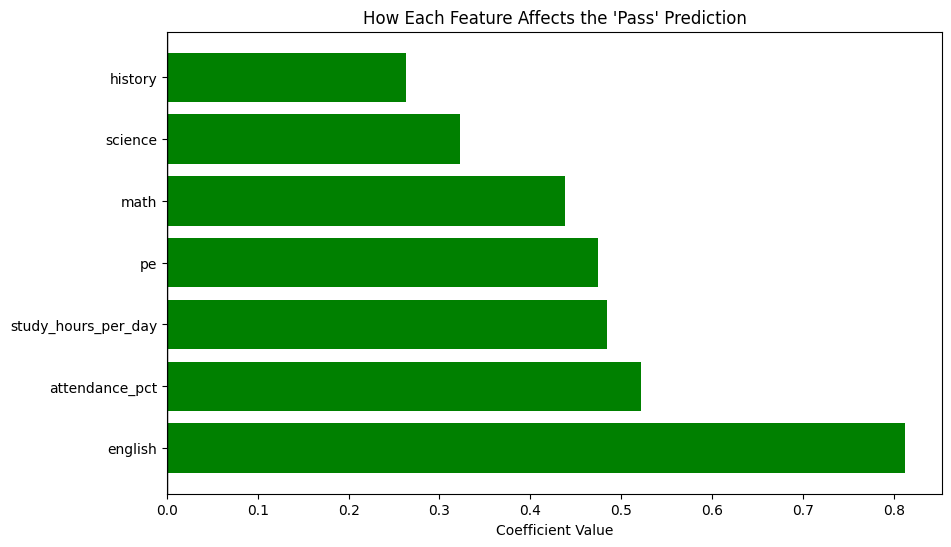

--- Bonus Prediction ---
New Student Prediction: Pass
Probability of Passing: 90.80%


In [10]:
## --- Task 4: Machine Learning with scikit-learn ---

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

# --- Step 1: Prepare Data ---
# We exclude 'name' and our target 'passed' from the features
X = df[['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']]
y = df['passed']

# Splitting: 80% for training the brain, 20% for testing it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling: Logistic Regression works better when all numbers are on a similar scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Step 2: Train the Model ---
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Check accuracy on the data it already saw
train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
print(f"Model Training Accuracy: {train_acc:.2%}")

# --- Step 3: Evaluate the Model ---
y_pred = model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, y_pred)
print(f"Model Test Accuracy: {test_acc:.2%}\n")

print("--- Individual Test Predictions ---")
# Using .loc and X_test.index to match names back to our results
test_student_names = df.loc[X_test.index, 'name'].values

for name, actual, pred in zip(test_student_names, y_test, y_pred):
    result_icon = "✅ Correct" if actual == pred else "❌ Wrong"
    print(f"Student: {name} | Actual: {actual} | Predicted: {pred} ({result_icon})")

# --- Step 4: Feature Importance ---
# Pulling the coefficients to see which subject matters most
importance = model.coef_[0]
feature_names = X.columns

# Sorting them so the most influential feature is at the top
sorted_indices = np.argsort(np.abs(importance))[::-1]

print("\n--- Feature Importance (Highest Influence First) ---")
for i in sorted_indices:
    print(f"{feature_names[i]}: {importance[i]:.4f}")

# Plotting Feature Importance
plt.figure(figsize=(10, 6))
# Green for features that help you pass, Red for those that pull you toward failing
colors = ['green' if c > 0 else 'red' for c in importance[sorted_indices]]

plt.barh(feature_names[sorted_indices], importance[sorted_indices], color=colors)
plt.title("How Each Feature Affects the 'Pass' Prediction")
plt.xlabel("Coefficient Value")
plt.axvline(0, color='black', lw=1) # Adds a center line at zero
plt.savefig("plot8_importance.png")
plt.show()

# # --- Step 5: Bonus - Predict for a New Student ---
# Define features in the exact same order as your X DataFrame
feature_cols = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
new_student_data = [[75, 70, 68, 65, 80, 82, 3.2]]

# Wrap it in a DataFrame so the Scaler doesn't complain about missing names
new_student_df = pd.DataFrame(new_student_data, columns=feature_cols)

# Scale using the same scaler we used for the training data
new_student_scaled = scaler.transform(new_student_df)

# Get prediction and probability
new_pred = model.predict(new_student_scaled)[0]
new_proba = model.predict_proba(new_student_scaled)[0]

status = "Pass" if new_pred == 1 else "Fail"
print(f"--- Bonus Prediction ---")
print(f"New Student Prediction: {status}")
print(f"Probability of Passing: {new_proba[1]:.2%}")